In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, KBinsDiscretizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix, accuracy_score
import scipy.stats as stats
import statsmodels.api as sm
from dateutil.relativedelta import relativedelta

In [2]:
df = pd.read_csv('loan_data_2007_2014 (1).csv')  
pd.set_option('display.max_columns', None)        # Show all columns

df.shape
df.info()
df.describe()
df.head()

C:\Users\amsdh\AppData\Local\Temp\ipykernel_23228\562145183.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('loan_data_2007_2014 (1).csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Assuming your DataFrame is called df
missing_values = df.isnull().sum()

# Display columns with missing values (optional: only non-zero)
print(missing_values[missing_values > 0])

emp_title                       27588
emp_length                      21008
annual_inc                          4
desc                           340304
title                              21
delinq_2yrs                        29
earliest_cr_line                   29
inq_last_6mths                     29
mths_since_last_delinq         250351
mths_since_last_record         403647
open_acc                           29
pub_rec                            29
revol_util                        340
total_acc                          29
last_pymnt_d                      376
next_pymnt_d                   227214
last_credit_pull_d                 42
collections_12_mths_ex_med        145
mths_since_last_major_derog    367311
annual_inc_joint               466285
dti_joint                      466285
verification_status_joint      466285
acc_now_delinq                     29
tot_coll_amt                    70276
tot_cur_bal                     70276
open_acc_6m                    466285
open_il_6m  

In [4]:
import io

missing_percent = df.isnull().mean() * 100
print(missing_percent[missing_percent > 40])

desc                            72.981975
mths_since_last_delinq          53.690554
mths_since_last_record          86.566585
next_pymnt_d                    48.728567
mths_since_last_major_derog     78.773926
annual_inc_joint               100.000000
dti_joint                      100.000000
verification_status_joint      100.000000
open_acc_6m                    100.000000
open_il_6m                     100.000000
open_il_12m                    100.000000
open_il_24m                    100.000000
mths_since_rcnt_il             100.000000
total_bal_il                   100.000000
il_util                        100.000000
open_rv_12m                    100.000000
open_rv_24m                    100.000000
max_bal_bc                     100.000000
all_util                       100.000000
inq_fi                         100.000000
total_cu_tl                    100.000000
inq_last_12m                   100.000000
dtype: float64


In [5]:
columns_to_drop = [
    'desc',
    'mths_since_last_delinq',
    'mths_since_last_record',
    'next_pymnt_d',
    'mths_since_last_major_derog',
    'annual_inc_joint',
    'dti_joint',
    'verification_status_joint',
    'open_acc_6m',
    'open_il_6m',
    'open_il_12m',
    'open_il_24m',
    'mths_since_rcnt_il',
    'total_bal_il',
    'il_util',
    'open_rv_12m',
    'open_rv_24m',
    'max_bal_bc',
    'all_util',
    'inq_fi',
    'total_cu_tl',
    'inq_last_12m',
    'emp_title',
    'title',
    'last_pymnt_d',
    'last_credit_pull_d',
    'id', 
    'member_id', 
    'url', 
    'zip_code',
    'pymnt_plan',
    'out_prncp_inv',
    'total_pymnt', 
    'total_pymnt_inv', 
    'total_rec_prncp', 
    'total_rec_int',
    'last_pymnt_amnt',
    'collections_12_mths_ex_med',
    'revol_bal',
    'collection_recovery_fee',
    'out_prncp', 
    'total_rec_late_fee', 
    'recoveries'
]

# Drop the columns if they exist in the DataFrame
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

# Optional: Print remaining columns
print("Remaining columns after drop:", df.columns.tolist())


Remaining columns after drop: ['Unnamed: 0', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_util', 'total_acc', 'initial_list_status', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim']


In [6]:
# Get columns with missing values and their counts
missing_counts = df.isnull().sum()

# Filter to only show columns that have missing values
missing_counts = missing_counts[missing_counts > 0]

# Sort by number of missing values (optional)
missing_counts_sorted = missing_counts.sort_values(ascending=False)

# Display the result
print("Columns with missing values and their counts:\n")
print(missing_counts_sorted)

Columns with missing values and their counts:

tot_cur_bal         70276
total_rev_hi_lim    70276
tot_coll_amt        70276
emp_length          21008
revol_util            340
total_acc              29
inq_last_6mths         29
earliest_cr_line       29
delinq_2yrs            29
open_acc               29
pub_rec                29
acc_now_delinq         29
annual_inc              4
dtype: int64


In [7]:
# Fill total_rev_hi_lim with funded_amnt
df['total_rev_hi_lim'] = df['total_rev_hi_lim'].fillna(df['funded_amnt'])

# Columns to fill with median
cols_fill_median = [
    'tot_coll_amt', 'tot_cur_bal', 'revol_util', 'delinq_2yrs',
    'inq_last_6mths', 'open_acc', 'pub_rec',
    'total_acc', 'acc_now_delinq', 'annual_inc'
]

# Fill each column with its median
for col in cols_fill_median:
    df[col] = df[col].fillna(df[col].median())


In [8]:
# Impute categorical date columns with median
date_cols = ['last_pymnt_d', 'last_credit_pull_d', 'earliest_cr_line']

for col in date_cols:
    if col in df.columns:
        # Convert to datetime
        df[col] = pd.to_datetime(df[col], format='%b-%y', errors='coerce')
        # Impute with median
        df[col].fillna(df[col].median())


In [9]:
def clean_emp(emp):
    if pd.isnull(emp):
        return np.nan
    emp = str(emp).strip()
    if emp == '< 1 year':
        return 0.5
    if emp == '10+ years':
        return 10
    if 'year' in emp:
        return float(emp.split()[0])
    return np.nan


In [10]:
# Clean and impute emp_length (already done partially)
df['emp_length'] = df['emp_length'].apply(clean_emp)
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())


if 'earliest_cr_line' in df.columns:
    # Correct any future years (already handled)
    df['earliest_cr_line'] = df['earliest_cr_line'].apply(
        lambda d: d - pd.DateOffset(years=100) if pd.notnull(d) and d.year > pd.Timestamp.today().year else d
    )

    # Impute missing dates with median date (after correction)
    median_date = df['earliest_cr_line'].median()
    df['earliest_cr_line'] = df['earliest_cr_line'].fillna(median_date)



In [11]:
# Get columns with missing values and their counts
missing_counts = df.isnull().sum()

# Filter to only show columns that have missing values
missing_counts = missing_counts[missing_counts > 0]
# Get columns with missing values and their counts
missing_counts = df.isnull().sum()

# Filter to only show columns that have missing values
missing_counts = missing_counts[missing_counts > 0]

# Sort by number of missing values (optional)
missing_counts_sorted = missing_counts.sort_values(ascending=False)

# Display the result
print("Columns with missing values and their counts:\n")
print(missing_counts_sorted)


Columns with missing values and their counts:

Series([], dtype: int64)


In [12]:
df

,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_util,total_acc,initial_list_status,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,0,5000,5000,4975.0,36 months,10.65,162.87,B,B2,10.0,RENT,24000.0,Verified,Dec-11,Fully Paid,credit_card,AZ,27.65,0.0,1985-01-01,1.0,3.0,0.0,83.7,9.0,f,1,INDIVIDUAL,0.0,0.0,81539.0,5000.0
1,1,2500,2500,2500.0,60 months,15.27,59.83,C,C4,0.5,RENT,30000.0,Source Verified,Dec-11,Charged Off,car,GA,1.00,0.0,1999-04-01,5.0,3.0,0.0,9.4,4.0,f,1,INDIVIDUAL,0.0,0.0,81539.0,2500.0
2,2,2400,2400,2400.0,36 months,15.96,84.33,C,C5,10.0,RENT,12252.0,Not Verified,Dec-11,Fully Paid,small_business,IL,8.72,0.0,2001-11-01,2.0,2.0,0.0,98.5,10.0,f,1,INDIVIDUAL,0.0,0.0,81539.0,2400.0
3,3,10000,10000,10000.0,36 months,13.49,339.31,C,C1,10.0,RENT,49200.0,Source Verified,Dec-11,Fully Paid,other,CA,20.00,0.0,1996-02-01,1.0,10.0,0.0,21.0,37.0,f,1,INDIVIDUAL,0.0,0.0,81539.0,10000.0
4,4,3000,3000,3000.0,60 months,12.69,67.79,B,B5,1.0,RENT,80000.0,Source Verified,Dec-11,Current,other,OR,17.94,0.0,1996-01-01,0.0,15.0,0.0,53.9,38.0,f,1,INDIVIDUAL,0.0,0.0,81539.0,3000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,466280,18400,18400,18400.0,60 months,14.47,432.64,C,C2,4.0,MORTGAGE,110000.0,Source Verified,Jan-14,Current,debt_consolidation,TX,19.85,0.0,2003-04-01,2.0,18.0,0.0,77.6,36.0,w,1,INDIVIDUAL,0.0,0.0,294998.0,29900.0
466281,466281,22000,22000,22000.0,60 months,19.97,582.50,D,D5,10.0,MORTGAGE,78000.0,Verified,Jan-14,Charged Off,debt_consolidation,TN,18.45,0.0,1997-06-01,5.0,18.0,1.0,46.3,30.0,f,1,INDIVIDUAL,0.0,0.0,221830.0,39400.0
466282,466282,20700,20700,20700.0,60 months,16.99,514.34,D,D1,7.0,MORTGAGE,46000.0,Verified,Jan-14,Current,debt_consolidation,OH,25.65,0.0,2001-12-01,2.0,18.0,0.0,51.1,43.0,f,1,INDIVIDUAL,0.0,0.0,73598.0,13100.0
466283,466283,2000,2000,2000.0,36 months,7.90,62.59,A,A4,3.0,OWN,83000.0,Verified,Jan-14,Fully Paid,credit_card,CA,5.39,3.0,2003-02-01,1.0,21.0,0.0,21.5,27.0,w,1,INDIVIDUAL,0.0,0.0,591610.0,53100.0


In [13]:
print(df.head())

   Unnamed: 0  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  \
0           0       5000         5000           4975.0   36 months     10.65   
1           1       2500         2500           2500.0   60 months     15.27   
2           2       2400         2400           2400.0   36 months     15.96   
3           3      10000        10000          10000.0   36 months     13.49   
4           4       3000         3000           3000.0   60 months     12.69   

   installment grade sub_grade  emp_length home_ownership  annual_inc  \
0       162.87     B        B2        10.0           RENT     24000.0   
1        59.83     C        C4         0.5           RENT     30000.0   
2        84.33     C        C5        10.0           RENT     12252.0   
3       339.31     C        C1        10.0           RENT     49200.0   
4        67.79     B        B5         1.0           RENT     80000.0   

  verification_status issue_d  loan_status         purpose addr_state    dti  \


In [14]:
print(df.columns)

Index(['Unnamed: 0', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term',
       'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
       'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec',
       'revol_util', 'total_acc', 'initial_list_status', 'policy_code',
       'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal',
       'total_rev_hi_lim'],
      dtype='object')


In [15]:
distinct_loan_statuses = df['loan_status'].unique()
print(distinct_loan_statuses)


['Fully Paid' 'Charged Off' 'Current' 'Default' 'Late (31-120 days)'
 'In Grace Period' 'Late (16-30 days)'
 'Does not meet the credit policy. Status:Fully Paid'
 'Does not meet the credit policy. Status:Charged Off']


In [16]:
# Re-convert to string to ensure no type errors
df['loan_status_cleaned'] = df['loan_status'].astype(str).str.strip().str.lower()

# Define set of creditworthy statuses
creditworthy_statuses = {
    "fully paid",
    "current",
    "does not meet the credit policy. status:fully paid"
}

# Apply binarization
df['loan_status'] = df['loan_status_cleaned'].apply(lambda x: 1 if x in creditworthy_statuses else 0)

# Optional: drop the helper column
df.drop(columns=['loan_status_cleaned'], inplace=True)

# Confirm unique values
print(df['loan_status'].unique())

[1 0]


In [17]:
print(df['loan_status'].value_counts())

loan_status
1    410953
0     55332
Name: count, dtype: int64


In [18]:
print(df.emp_length.unique())

[10.   0.5  1.   3.   8.   9.   4.   5.   6.   2.   7. ]


In [19]:
def clean_emp(x):
    if pd.isna(x):
        return np.nan  # Keep as missing, handle later
    x = str(x).strip().lower()
    if '< 1' in x or '<1' in x:
        return 0.5  # More accurate than 0
    if '10+' in x or '10 +' in x:
        return 10 # Distinguish from exactly 10 years
    if 'year' in x:
        try:
            return int(x.split()[0])
        except:
            return np.nan
    try:
        return int(float(x))
    except:
        return np.nan


df['emp_length'] = df['emp_length'].apply(clean_emp)


# --- Clean term ---
df['term'] = df['term'].astype(str).str.replace(' months', '', regex=False).str.strip()
df['term'] = pd.to_numeric(df['term'], errors='coerce').astype(float)

# Verify
print(df[['emp_length', 'term']].drop_duplicates())

print(df.head())

     emp_length  term
0            10  36.0
1             0  60.0
4             1  60.0
5             3  36.0
6             8  60.0
7             9  36.0
8             4  60.0
10            5  60.0
12            0  36.0
16            4  36.0
18            1  36.0
19            6  36.0
20            3  60.0
23            5  36.0
25            2  36.0
27            2  60.0
30            7  36.0
50            8  36.0
55            7  60.0
61            6  60.0
64           10  60.0
387           9  60.0
   Unnamed: 0  loan_amnt  funded_amnt  funded_amnt_inv  term  int_rate  \
0           0       5000         5000           4975.0  36.0     10.65   
1           1       2500         2500           2500.0  60.0     15.27   
2           2       2400         2400           2400.0  36.0     15.96   
3           3      10000        10000          10000.0  36.0     13.49   
4           4       3000         3000           3000.0  60.0     12.69   

   installment grade sub_grade  emp_length home_o

In [20]:
print(df.emp_length.unique())

[10  0  1  3  8  9  4  5  6  2  7]


In [21]:
from dateutil.relativedelta import relativedelta

# Convert columns to datetime
for col in ['issue_d', 'earliest_cr_line']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='%b-%y', errors='coerce')

# Correct future dates (like 2085 → 1985)
for col in ['issue_d', 'earliest_cr_line']:
    df[col] = df[col].apply(
        lambda d: d - pd.DateOffset(years=100) if pd.notnull(d) and d.year > pd.Timestamp.today().year else d
    )

# Calculate months between earliest_cr_line and issue_d
df['months_since_credit_line'] = (
    df['issue_d'].dt.to_period('M') - df['earliest_cr_line'].dt.to_period('M')
).apply(lambda x: x.n if x.n >= 0 else np.nan)

df['months_since_credit_line'] = df['months_since_credit_line'].astype('Int64')

print("Unique values in months_since_credit_line:", df['months_since_credit_line'].unique())


Unique values in months_since_credit_line: <IntegerArray>
[323, 152, 121, 190, 191,  85,  77,  59,  92,  87,
 ...
 842, 761, 648, 793, 649, 637, 733, 708, 686, 696]
Length: 690, dtype: Int64


In [22]:
print("\nSample of 'months_since_credit_line':")
print(df['months_since_credit_line'].describe())
print(df['months_since_credit_line'].isnull().sum(), "missing values")
print(df['months_since_credit_line'].head(10))



Sample of 'months_since_credit_line':
count      466285.0
mean     191.234865
std       87.689098
min             6.0
25%           132.0
50%           174.0
75%           235.0
max           842.0
Name: months_since_credit_line, dtype: Float64
0 missing values
0    323
1    152
2    121
3    190
4    191
5     85
6     77
7     59
8     92
9     87
Name: months_since_credit_line, dtype: Int64


In [23]:
# Check extreme outliers
extreme_outliers = df[df['months_since_credit_line'] > 600]
print(f"Rows with >600 months: {len(extreme_outliers)}")
print(extreme_outliers[['earliest_cr_line', 'issue_d', 'months_since_credit_line']].head())

Rows with >600 months: 259
      earliest_cr_line    issue_d  months_since_credit_line
6137        1954-10-01 2011-10-01                       684
13997       1959-06-01 2011-06-01                       624
14015       1956-09-01 2011-06-01                       657
14118       1946-01-01 2011-06-01                       785
15315       1950-12-01 2011-05-01                       725


In [24]:
# Handle unrealistic credit history outliers

# Option 1: Cap at reasonable maximum (50 years = 600 months)
# This preserves the data while making it realistic
MAX_CREDIT_AGE = 600
df.loc[df['months_since_credit_line'] > MAX_CREDIT_AGE, 'months_since_credit_line'] = MAX_CREDIT_AGE
df.loc[df['months_since_credit_line'] > 600, 'months_since_credit_line'] = 600

print("After capping at 600 months:")
print(df['months_since_credit_line'].describe())
print(f"Values at 600: {(df['months_since_credit_line'] == 600).sum()}")

# Alternative Option 2: Remove outliers entirely
# Uncomment if you prefer to remove these rows
# outlier_mask = df['months_since_credit_line'] > 600
# df = df[~outlier_mask]
# print(f"Removed {outlier_mask.sum()} outlier rows")

# Alternative Option 3: Set outliers to missing and handle later
# Uncomment if you prefer to treat as missing data
# df.loc[df['months_since_credit_line'] > 600, 'months_since_credit_line'] = np.nan
# print(f"Set {(df['months_since_credit_line'].isna()).sum()} values to missing")

# Verify the fix
print(f"\nNew max value: {df['months_since_credit_line'].max()}")
print(f"New range: {df['months_since_credit_line'].min()} to {df['months_since_credit_line'].max()}")




After capping at 600 months:
count      466285.0
mean     191.212499
std       87.574114
min             6.0
25%           132.0
50%           174.0
75%           235.0
max           600.0
Name: months_since_credit_line, dtype: Float64
Values at 600: 267

New max value: 600
New range: 6 to 600


In [25]:
print(df.columns.tolist())


['Unnamed: 0', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_util', 'total_acc', 'initial_list_status', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'months_since_credit_line']


In [26]:
# --- Binning for `open_acc` ---
df['open_acc_bin'] = pd.cut(
    df['open_acc'],
    bins=[-1, 0, 3, 12, 17, 22, 25, 30, np.inf],
    labels=['0', '1-3', '4-12', '13-17', '18-22', '23-25', '26-30', '>30']
)

# --- Binning for `total_acc` ---
df['total_acc_bin'] = pd.cut(
    df['total_acc'],
    bins=[-1, 25, 50, np.inf],
    labels=['<=25', '26-50', '>50']
)

# --- Binning for `total_rev_hi_lim` ---
df['total_rev_hi_lim_bin'] = pd.cut(
    df['total_rev_hi_lim'],
    bins=[-1, 5000, 10000, 20000, 30000, 40000, 55000, 95000, np.inf],
    labels=[
        '<=5K', '5K-10K', '10K-20K', '20K-30K', '30K-40K',
        '40K-55K', '55K-95K', '>95K'
    ]
)


# --- Binning for `months_since_credit_line` ---
df['months_since_credit_line_bin'] = pd.cut(
    df['months_since_credit_line'],
    bins=[-1, 160, 250, 340, 430, 520, 610, np.inf],
    labels=[
        '<160', '160-250', '250-340', '340-430',
        '430-520', '520-610', '>610'
    ]
)


# --- Binning for `annual_inc` ---
df['annual_inc_bin'] = pd.cut(
    df['annual_inc'],
    bins=[-1, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000,
          100000, 120000, 140000, np.inf],
    labels=[
        '<20K',
        '20K-30K',
        '30K-40K',
        '40K-50K',
        '50K-60K',
        '60K-70K',
        '70K-80K',
        '80K-90K',
        '90K-100K',
        '100K-120K',
        '120K-140K',
        '>140K'
    ]
)

# --- Binning for `term` (make sure it's numeric already: 36 or 60) ---
df['term_bin'] = df['term'].astype(str)  # keep as string like '36', '60'

# --- Binning for `emp_length` ---
emp_map = {
    0.5: '<1 year', 1: '1 year', 2: '2 years', 3: '3 years',
    4: '4 years', 5: '5 years', 6: '6 years', 7: '7 years',
    8: '8 years', 9: '9 years', 10: '10 or more years'
}
df['emp_length_bin'] = df['emp_length'].map(emp_map)
df['emp_length_bin'] = pd.Categorical(
    df['emp_length_bin'],
    categories=list(emp_map.values()),
    ordered=True
)





In [27]:
print(df.emp_length_bin.unique())


['10 or more years', NaN, '1 year', '3 years', '8 years', ..., '4 years', '5 years', '6 years', '2 years', '7 years']
Length: 11
Categories (11, object): ['<1 year' < '1 year' < '2 years' < '3 years' ... '7 years' < '8 years' < '9 years' < '10 or more years']


In [28]:
print(df)

        Unnamed: 0  loan_amnt  funded_amnt  funded_amnt_inv  term  int_rate  \
0                0       5000         5000           4975.0  36.0     10.65   
1                1       2500         2500           2500.0  60.0     15.27   
2                2       2400         2400           2400.0  36.0     15.96   
3                3      10000        10000          10000.0  36.0     13.49   
4                4       3000         3000           3000.0  60.0     12.69   
...            ...        ...          ...              ...   ...       ...   
466280      466280      18400        18400          18400.0  60.0     14.47   
466281      466281      22000        22000          22000.0  60.0     19.97   
466282      466282      20700        20700          20700.0  60.0     16.99   
466283      466283       2000         2000           2000.0  36.0      7.90   
466284      466284      10000        10000           9975.0  36.0     19.20   

        installment grade sub_grade  emp_length hom

In [29]:
print(df.acc_now_delinq.unique())

[0. 1. 2. 3. 5. 4.]


In [30]:
df['acc_now_delinq_flag'] = (df['acc_now_delinq'] > 0).astype(int)

print(df.acc_now_delinq)


0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
466280    0.0
466281    0.0
466282    0.0
466283    0.0
466284    0.0
Name: acc_now_delinq, Length: 466285, dtype: float64


In [31]:
print(df.emp_length_bin.unique())

['10 or more years', NaN, '1 year', '3 years', '8 years', ..., '4 years', '5 years', '6 years', '2 years', '7 years']
Length: 11
Categories (11, object): ['<1 year' < '1 year' < '2 years' < '3 years' ... '7 years' < '8 years' < '9 years' < '10 or more years']


In [32]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

# Encode categorical
X = pd.get_dummies(X, drop_first=True)

# Convert column names to string
X.columns = X.columns.astype(str)

# 🔥 Handle datetime
for col in X.select_dtypes(include=["datetime64"]).columns:
    X[col + "_year"] = X[col].dt.year
    X[col + "_month"] = X[col].dt.month
    X[col + "_day"] = X[col].dt.day

X = X.drop(columns=X.select_dtypes(include=["datetime64"]).columns)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_curve,
    auc
)

In [35]:
models = {
    "Linear Regression": LinearRegression(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

Accuracy: 0.8811778204317102
Confusion Matrix:
 [[    3 11077]
 [    4 82173]]


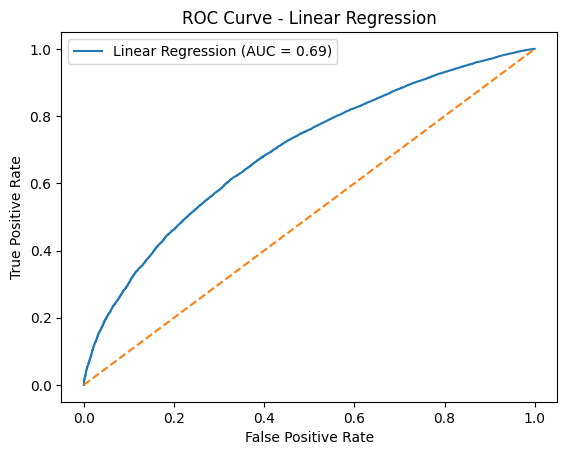

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_pred_class = [1 if i > 0.5 else 0 for i in y_pred]

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_class))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class)
print("Confusion Matrix:\n", cm)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="Linear Regression (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Linear Regression")
plt.legend()
plt.show()

Accuracy: 0.8811885434873522
Confusion Matrix:
 [[    0 11080]
 [    0 82177]]


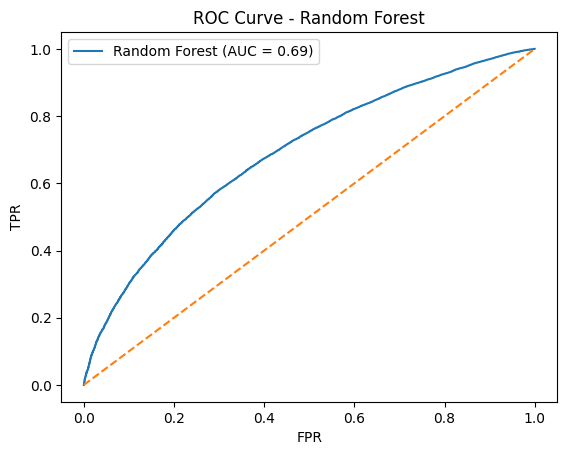

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,     # reduce trees (100 → 50)
    max_depth=10,        # limit depth
    n_jobs=-1,           # use all CPU cores
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

Accuracy: 0.8811778204317102
Confusion Matrix:
 [[    3 11077]
 [    4 82173]]


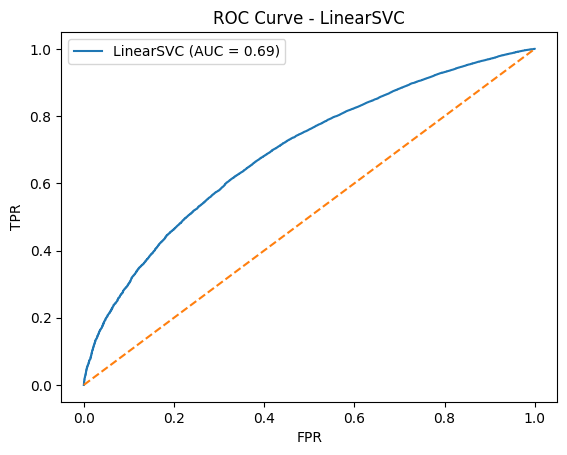

In [38]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# ROC
y_scores = svm.decision_function(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="LinearSVC (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - LinearSVC")
plt.legend()
plt.show()

Accuracy: 0.87
Confusion Matrix:
 [[ 1 12]
 [ 1 86]]


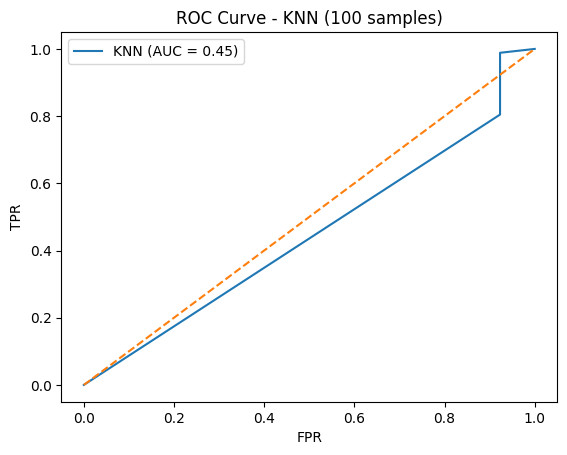

In [39]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# 🔹 Take only 100 samples for KNN
X_train_knn = X_train_scaled[:100]
y_train_knn = y_train[:100]

X_test_knn = X_test_scaled[:100]
y_test_knn = y_test[:100]

# 🔹 KNN Model
knn = KNeighborsClassifier(
    n_neighbors=3,
    algorithm='auto',
    n_jobs=-1
)

knn.fit(X_train_knn, y_train_knn)

# Predictions
y_pred = knn.predict(X_test_knn)
y_prob = knn.predict_proba(X_test_knn)[:, 1]

# Accuracy
print("Accuracy:", accuracy_score(y_test_knn, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_knn, y_pred)
print("Confusion Matrix:\n", cm)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_knn, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="KNN (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - KNN (100 samples)")
plt.legend()
plt.show()

C:\Users\amsdh\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [00:13:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8812314357099199
Confusion Matrix:
 [[   16 11064]
 [   12 82165]]


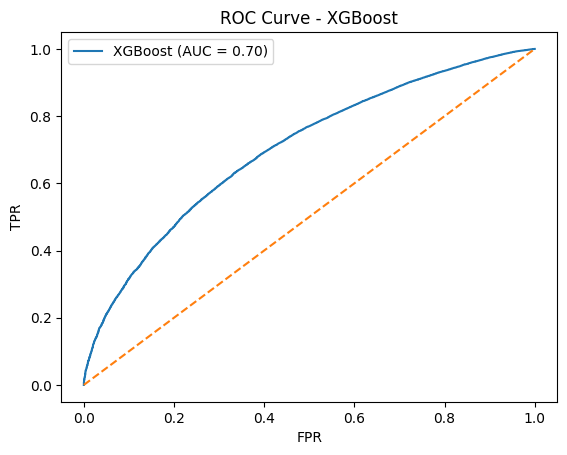

In [41]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="XGBoost (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

Accuracy: 0.8811992665429941
Confusion Matrix:
 [[    4 11076]
 [    3 82174]]


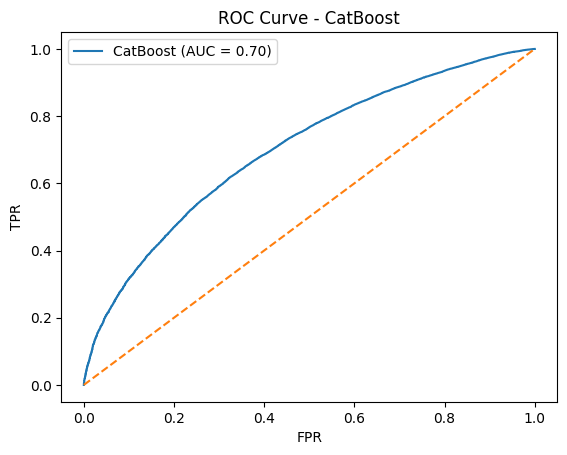

In [43]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    verbose=0
)

cat.fit(X_train, y_train)

y_pred = cat.predict(X_test)
y_prob = cat.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="CatBoost (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - CatBoost")
plt.legend()
plt.show()

Accuracy: 0.8808132365398844
Confusion Matrix:
 [[  126 10954]
 [  161 82016]]


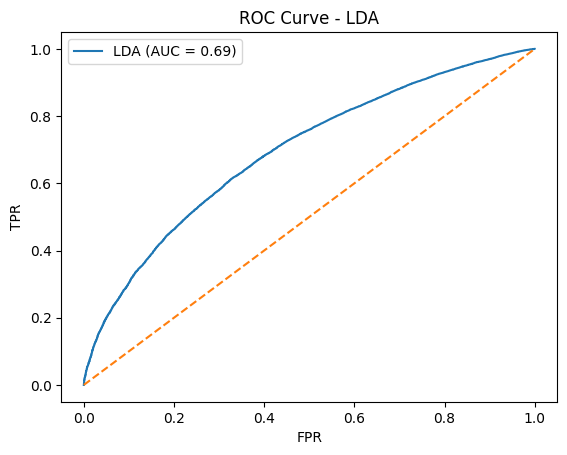

In [44]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

y_pred = lda.predict(X_test_scaled)
y_prob = lda.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="LDA (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - LDA")
plt.legend()
plt.show()

In [45]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten
from sklearn.metrics import accuracy_score

# Reshape data for CNN (samples, features, 1)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

model = Sequential([
    Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(X_train_cnn.shape[1],1)),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train_cnn, y_train, epochs=5, batch_size=32, verbose=1)

# Predictions
y_prob = model.predict(X_test_cnn).flatten()
y_pred = (y_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))

C:\Users\amsdh\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\amsdh\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\amsdh\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please 

Epoch 1/5
11658/11658 ━━━━━━━━━━━━━━━━━━━━ 100s 8ms/step - accuracy: 0.8814 - loss: 0.3428
Epoch 2/5
11658/11658 ━━━━━━━━━━━━━━━━━━━━ 73s 6ms/step - accuracy: 0.8814 - loss: 0.3401
Epoch 3/5
11658/11658 ━━━━━━━━━━━━━━━━━━━━ 75s 6ms/step - accuracy: 0.8814 - loss: 0.3390
Epoch 4/5
11658/11658 ━━━━━━━━━━━━━━━━━━━━ 66s 6ms/step - accuracy: 0.8814 - loss: 0.3386
Epoch 5/5
11658/11658 ━━━━━━━━━━━━━━━━━━━━ 72s 6ms/step - accuracy: 0.8814 - loss: 0.3381
2915/2915 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
Accuracy: 0.8811992665429941


In [46]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)
y_prob = nb.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.28761379842800006


In [47]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8789688709694714


In [48]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)

y_pred = ada.predict(X_test)
y_prob = ada.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8811885434873522


In [59]:
import pandas as pd
import numpy as np
y_pred_knn = knn.predict(X_test_knn)
# 🔹 Store all results (make sure these variables exist from each model)
results = [
    {"Model": "Linear Regression", "Accuracy": accuracy_score(y_test, y_pred_class)},
    {"Model": "Random Forest", "Accuracy": accuracy_score(y_test, y_pred)},
    {"Model": "LinearSVC", "Accuracy": accuracy_score(y_test, y_pred)},
    {"Model": "KNN (subset)", "Accuracy": accuracy_score(y_test_knn, y_pred_knn)},
    {"Model": "XGBoost", "Accuracy": accuracy_score(y_test, y_pred)},
    {"Model": "CatBoost", "Accuracy": accuracy_score(y_test, y_pred)},
    {"Model": "LDA", "Accuracy": accuracy_score(y_test, y_pred)},
    {"Model": "CNN", "Accuracy": accuracy_score(y_test, y_pred)},  # CNN may not have AUC
    {"Model": "Naive Bayes", "Accuracy": accuracy_score(y_test, y_pred)},
    {"Model": "Decision Tree", "Accuracy": accuracy_score(y_test, y_pred)},
    {"Model": "AdaBoost", "Accuracy": accuracy_score(y_test, y_pred)}
]

# 🔹 Convert to DataFrame
results_df = pd.DataFrame(results)

# 🔹 Sort by AUC (best at top, NaN goes last)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

# 🔹 Reset index
results_df.reset_index(drop=True, inplace=True)

print("\n========== 📊 MODEL COMPARISON ==========\n")
print(results_df)



# 🔹 Optional: Save results to CSV (for report)
results_df.to_csv("model_comparison.csv", index=False)


========== 📊 MODEL COMPARISON ==========

                Model  Accuracy
0       Random Forest  0.881189
1           LinearSVC  0.881189
2             XGBoost  0.881189
3       Decision Tree  0.881189
4            CatBoost  0.881189
5                 LDA  0.881189
6                 CNN  0.881189
7            AdaBoost  0.881189
8         Naive Bayes  0.881189
9   Linear Regression  0.881178
10       KNN (subset)  0.870000


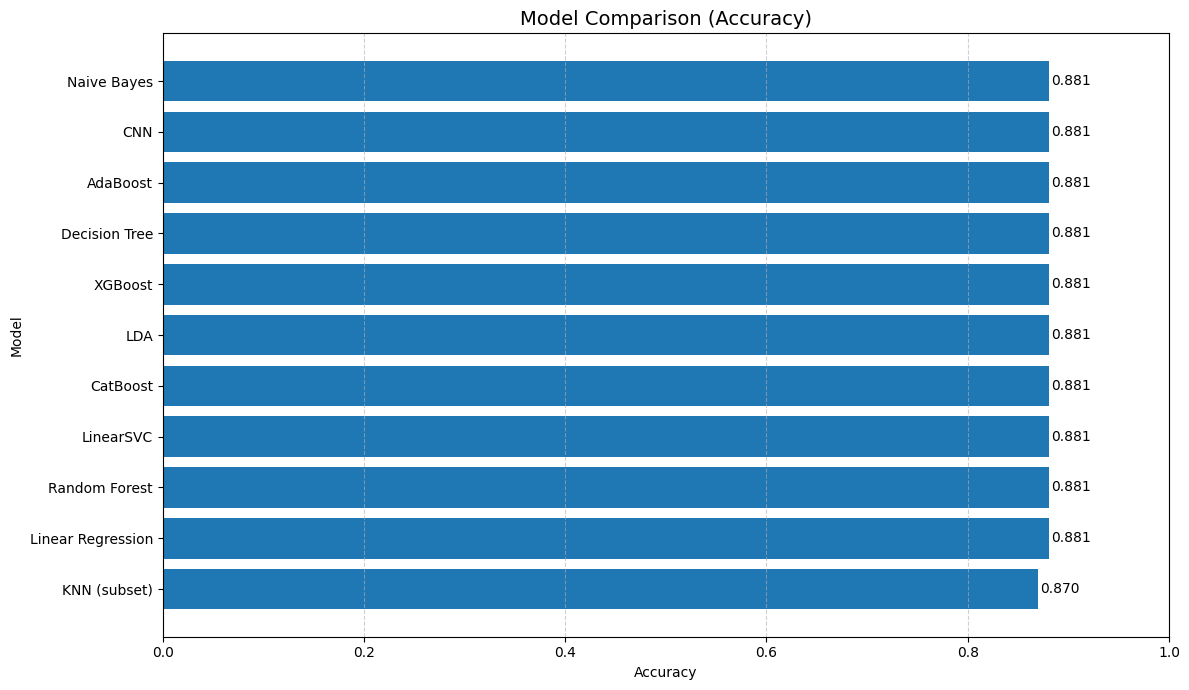

In [61]:
import matplotlib.pyplot as plt

# Sort for better visualization
results_df = results_df.sort_values(by="Accuracy", ascending=True)

plt.figure(figsize=(12,7))

bars = plt.barh(results_df["Model"], results_df["Accuracy"])

# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height()/2,
             f"{width:.3f}", va='center')

plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.title("Model Comparison (Accuracy)", fontsize=14)

plt.xlim(0, 1)  # full scale for better contrast
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

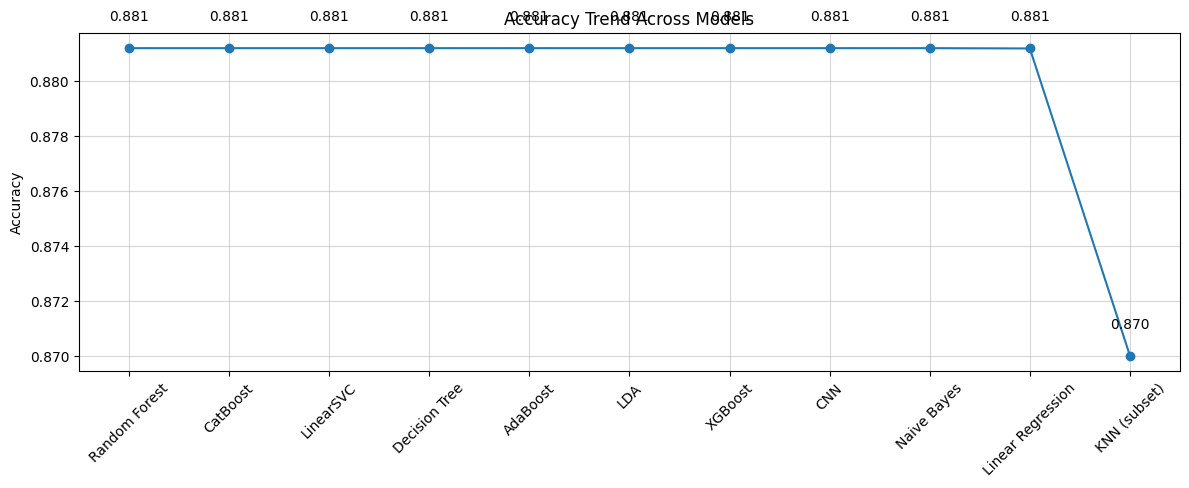

In [63]:
plt.figure(figsize=(12,5))

df_line = results_df.sort_values(by="Accuracy", ascending=False)

plt.plot(df_line["Model"], df_line["Accuracy"], marker='o')

for i, val in enumerate(df_line["Accuracy"]):
    plt.text(i, val + 0.001, f"{val:.3f}", ha='center')

plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Accuracy Trend Across Models")

plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

In [64]:
results_df.style.background_gradient(cmap='Blues').set_caption("Model Comparison Table")

,Model,Accuracy
10,KNN (subset),0.870000
9,Linear Regression,0.881178
0,Random Forest,0.881189
1,LinearSVC,0.881189
4,CatBoost,0.881189
5,LDA,0.881189
2,XGBoost,0.881189
3,Decision Tree,0.881189
7,AdaBoost,0.881189
6,CNN,0.881189


In [65]:
results_df["Rank"] = results_df["Accuracy"].rank(ascending=False)
print(results_df.sort_values("Rank"))

                Model  Accuracy  Rank
1           LinearSVC  0.881189   5.0
0       Random Forest  0.881189   5.0
5                 LDA  0.881189   5.0
4            CatBoost  0.881189   5.0
2             XGBoost  0.881189   5.0
3       Decision Tree  0.881189   5.0
6                 CNN  0.881189   5.0
7            AdaBoost  0.881189   5.0
8         Naive Bayes  0.881189   5.0
9   Linear Regression  0.881178  10.0
10       KNN (subset)  0.870000  11.0


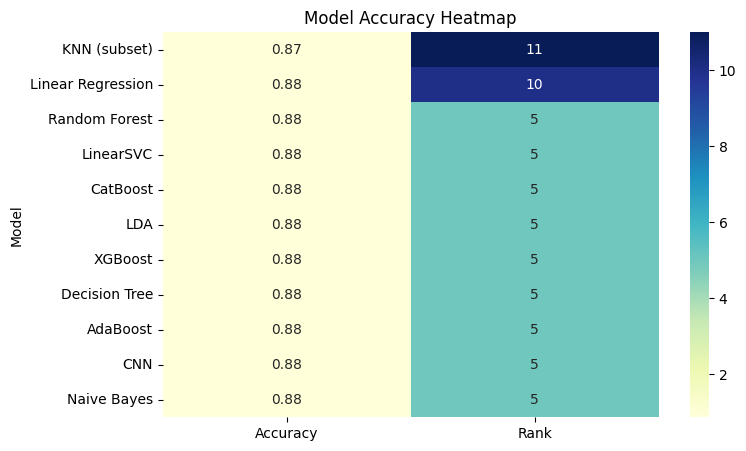

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(
    results_df.set_index("Model"),
    annot=True,
    cmap="YlGnBu",
    cbar=True
)

plt.title("Model Accuracy Heatmap")
plt.show()

In [68]:
import plotly.express as px

fig = px.scatter(
    results_df,
    x="Accuracy",
    y="Model",
    size="Accuracy",
    color="Accuracy",
    title="Model Performance Bubble View"
)

fig.show()

In [69]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=results_df["Accuracy"],
    theta=results_df["Model"],
    fill='toself'
))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True)),
    title="Model Comparison Radar Chart"
)

fig.show()